In [2]:
import pandas as pd

df = pd.read_csv(
    "customer_segmentation_processed.csv"
)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure_Group,Charge_Group,CLTV_Group,Cluster,Segment
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,1,86,3239,Competitor made better offer,New,Medium,Low Value,2,At-Risk Customers
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,1,67,2701,Moved,New,High,Low Value,2,At-Risk Customers
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,1,86,5372,Moved,New,Premium,High Value,3,New Customers
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,1,84,5003,Moved,Loyal,Premium,High Value,0,VIP Customers
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,1,89,5340,Competitor had better devices,Very Loyal,Premium,High Value,0,VIP Customers


In [3]:
df['Churn Label']

0       Yes
1       Yes
2       Yes
3       Yes
4       Yes
       ... 
7027     No
7028     No
7029     No
7030     No
7031     No
Name: Churn Label, Length: 7032, dtype: str

In [4]:
df['Churn Label'] = df['Churn Label'].map(
    {
        'No':0,
        'Yes':1
    }
)

In [5]:
df['Churn Label'].value_counts()

Churn Label
0    5163
1    1869
Name: count, dtype: int64

In [6]:
X = df.drop(
    columns=[
        'Churn Label',
        'CustomerID',
        'Count',
        'Lat Long',
        'Latitude',
        'Longitude',
        'Churn Reason',
        'Churn Value',
        'Churn Score'
    ]
)

y = df['Churn Label']

In [7]:
X.select_dtypes(include='object').columns

C:\Users\bhard\AppData\Local\Temp\ipykernel_20416\2418744409.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include='object').columns


Index(['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Tenure_Group', 'Charge_Group', 'CLTV_Group',
       'Segment'],
      dtype='str')

In [8]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [9]:
df['Churn Label'].value_counts(normalize=True)*100

Churn Label
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print(y_train.value_counts(normalize=True)*100)

print(y_test.value_counts(normalize=True)*100)

Churn Label
0    73.422222
1    26.577778
Name: proportion, dtype: float64
Churn Label
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [13]:
X = pd.get_dummies(
    X,
    drop_first=True
)

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True)*100)

print(y_test.value_counts(normalize=True)*100)

(5625, 1173)
(1407, 1173)
Churn Label
0    73.422222
1    26.577778
Name: proportion, dtype: float64
Churn Label
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

C:\Users\bhard\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = lr.predict(X_test)

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:")
print(
    accuracy_score(
        y_test,
        y_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy:
0.7967306325515281

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[907, 126],
       [160, 214]])

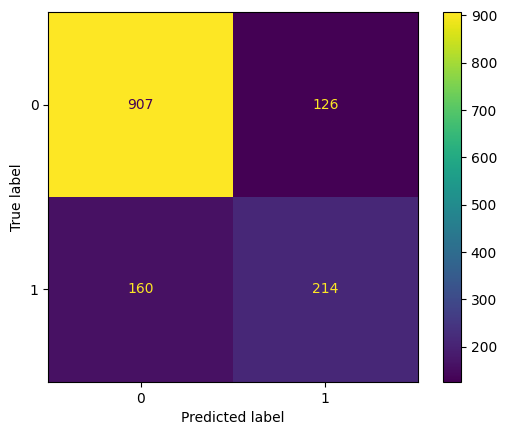

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [21]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

0.7938877043354655
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [22]:
confusion_matrix(
    y_test,
    rf_pred
)

array([[934,  99],
       [191, 183]])

In [23]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.8024164889836531
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [27]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(
    X_train,
    y_train
)

balanced_pred = lr_balanced.predict(
    X_test
)

C:\Users\bhard\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
print(classification_report(
    y_test,
    balanced_pred
))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [29]:
results = {
    'Model':['Logistic Regression',
             'Random Forest',
             'XGBoost'],
    
    'Accuracy':[0.7967,
                0.7939,
                0.8024],
    
    'Recall_Churn':[0.57,
                    0.49,
                    0.58],
    
    'F1_Churn':[0.60,
                0.56,
                0.61]
}

import pandas as pd

pd.DataFrame(results)

,Model,Accuracy,Recall_Churn,F1_Churn
0,Logistic Regression,0.7967,0.57,0.60
1,Random Forest,0.7939,0.49,0.56
2,XGBoost,0.8024,0.58,0.61


In [30]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
1141,Internet Service_Fiber optic,0.219246
1156,Contract_Two year,0.152022
1155,Contract_One year,0.092860
1142,Internet Service_No,0.048023
1137,Dependents_Yes,0.042242
1,Tenure Months,0.041885
1154,Streaming Movies_Yes,0.024932
1159,Payment Method_Electronic check,0.023095
1157,Paperless Billing_Yes,0.019554
1144,Online Security_Yes,0.019226


AUC Score: 0.8481565555906425


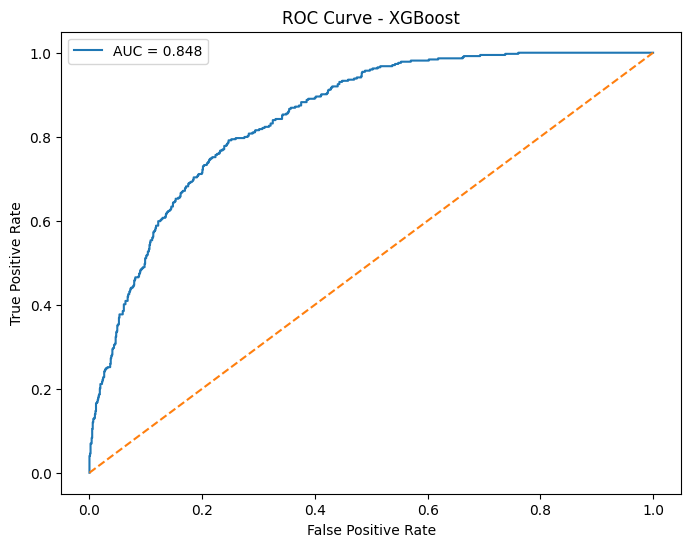

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()

plt.show()

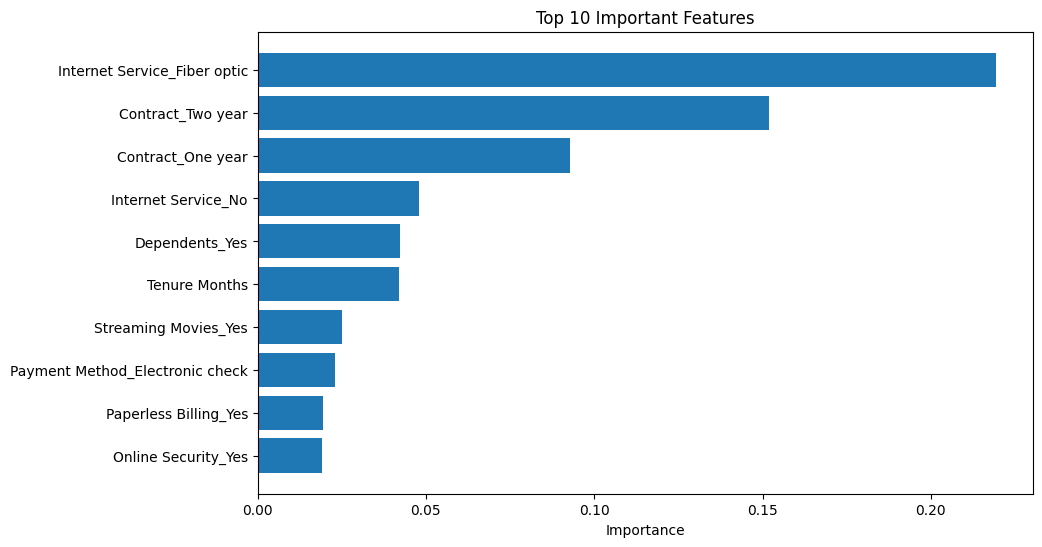

In [33]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance')

plt.gca().invert_yaxis()

plt.show()